In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('engineered_climate_features_correlation_analyzed.csv')

In [4]:
df

,location,tp_kharif_mean,tp_kharif_std,e_kharif_mean,e_kharif_std,swvl1_kharif_mean,soil_air_diff_kharif_mean,soil_air_diff_kharif_std,runoff_ratio_kharif_mean,e_rabi_mean,...,GDD_rabi,heat_months_30C,heat_months_35C,humidity_variability,swvl1_amplitude,swvl1_stability,soil_moisture_seasonality,cvh,water_retention_index,humidity_stress_index
0,A & N Islands_Nicobars,0.212075,0.009158,-0.144988,0.012498,5.571480e-07,1.401477,0.055918,0.000000,-0.124398,...,67.030034,0,0,0.403557,0.000005,9.164305,-3.721546e-07,0.000000,0.357962,8.448173
1,A & N Islands_North And Middle Andaman,0.337536,0.009329,-0.137305,0.010667,1.246314e-01,1.206633,0.090948,0.127147,-0.133948,...,66.739761,0,0,1.009721,0.082650,0.663154,2.567770e-02,0.097324,0.171858,3.615982
2,A & N Islands_South Andamans,0.311476,0.022785,-0.144685,0.010310,1.675441e-02,1.314073,0.136034,0.024587,-0.137583,...,67.797892,0,0,0.846505,0.010900,0.650601,3.163555e-03,0.009017,0.277637,4.320013
3,Andhra Pradesh_Alluri Sitharama Raju,0.312446,0.044864,-0.094966,0.003045,3.896810e-01,0.550737,0.154662,0.452236,-0.079284,...,50.285603,0,0,1.968619,0.238318,0.611573,1.239291e-01,0.737434,-0.059075,2.707588
4,Andhra Pradesh_Anakapalli,0.228586,0.028609,-0.107531,0.002641,2.852737e-01,0.548313,0.174455,0.237716,-0.086047,...,56.039035,1,0,0.958582,0.191011,0.669571,9.344429e-02,0.403020,-0.069854,4.945039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,West Bengal_Murshidabad,0.275707,0.021696,-0.112844,0.002819,3.844570e-01,0.641541,0.069157,0.356913,-0.073634,...,46.448733,2,0,1.888184,0.212852,0.553644,1.418102e-01,0.333241,-0.090637,2.708996
769,West Bengal_Nadia,0.278344,0.025523,-0.114582,0.002691,3.855084e-01,0.673007,0.080176,0.361696,-0.077410,...,47.466119,2,0,1.631112,0.208986,0.542105,1.389152e-01,0.082477,-0.103035,2.954232
770,West Bengal_Paschim Bardhaman,0.253455,0.021283,-0.109788,0.001778,3.772881e-01,0.754295,0.127140,0.257821,-0.070918,...,44.891160,3,0,2.463836,0.218843,0.580043,1.424418e-01,0.344329,-0.068096,2.365677
771,West Bengal_Purba Bardhaman,0.270052,0.023807,-0.110861,0.002242,3.840139e-01,0.635673,0.069839,0.336611,-0.072089,...,47.207326,3,0,1.842454,0.212822,0.554204,1.423393e-01,0.354676,-0.079435,2.812093


In [5]:
from sklearn.preprocessing import StandardScaler

# Separate location column
locations = df['location'].values

# Get all feature columns (exclude location and categorical variables)
feature_cols = [col for col in df.columns 
                if col not in ['location', 'cvh', 'cvl', 'slt']]

# Extract features
X = df[feature_cols].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

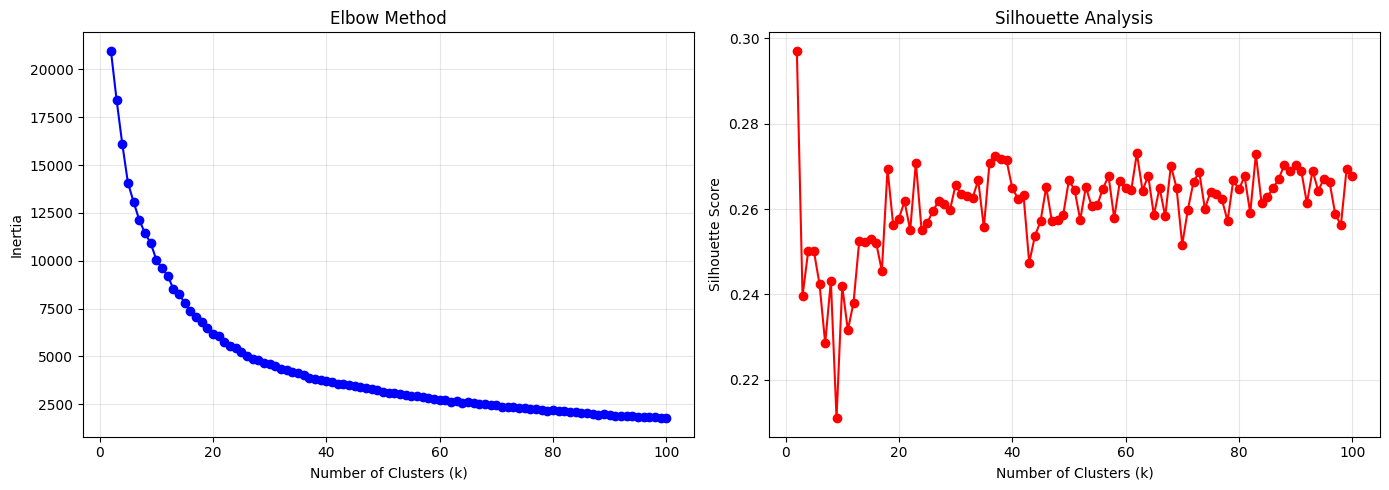

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

max_k = 100
inertias = []
silhouette_scores = []
k_range = range(2, max_k + 1)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels_temp))

# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



K-Means Evaluation:
  Number of clusters: 18
  Silhouette Score: 0.2694
  Davies-Bouldin Index: 1.1262
  Calinski-Harabasz Index: 132.00


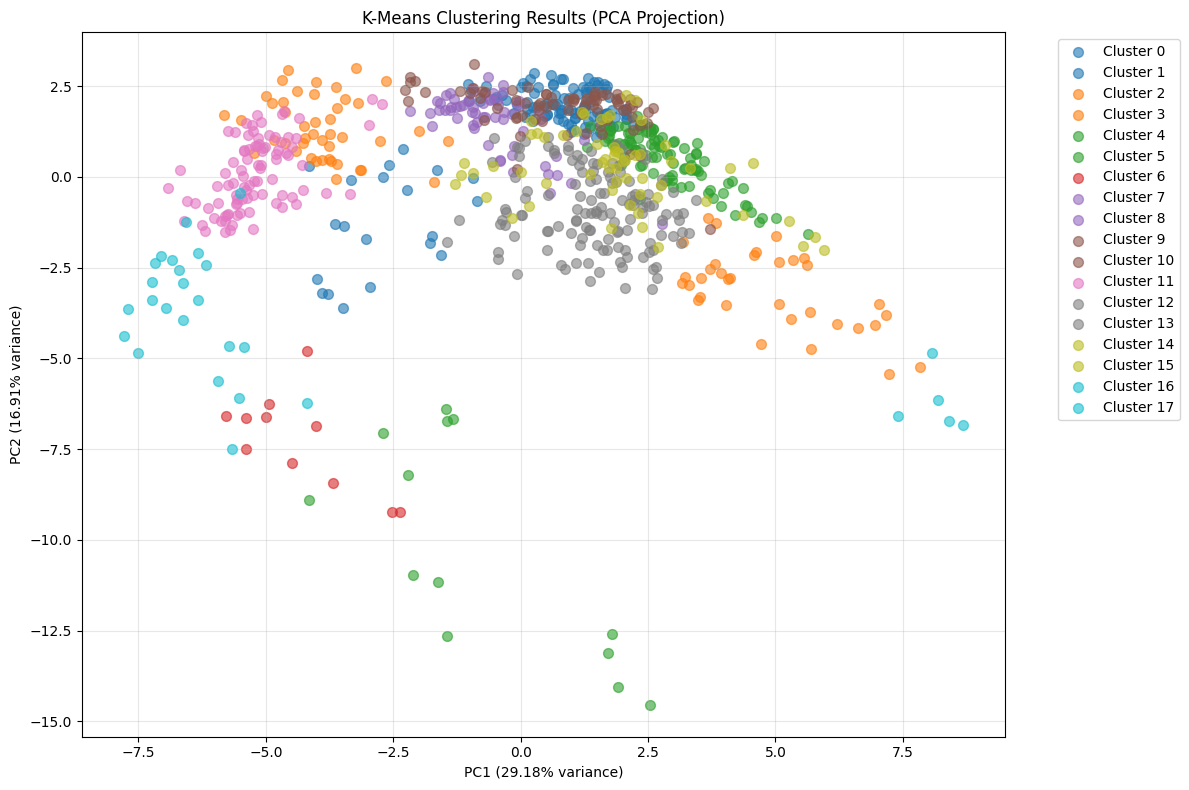


K-Means Cluster Summary:

Cluster 0:
  Size: 101 locations
  Sample locations: Bihar_Aurangabad, Bihar_Banka, Bihar_Gaya, Bihar_Jamui, Bihar_Kaimur (Bhabua)
  Avg annual rainfall: 0.28
  Avg annual temp: 0.85 K

Cluster 1:
  Size: 20 locations
  Sample locations: Himachal Pradesh_Bilaspur, Himachal Pradesh_Hamirpur, Himachal Pradesh_Kangra, Himachal Pradesh_Mandi, Himachal Pradesh_Shimla
  Avg annual rainfall: 0.29
  Avg annual temp: 0.68 K

Cluster 2:
  Size: 34 locations
  Sample locations: Gujarat_Kachchh, Haryana_Bhiwani, Haryana_Charki Dadri, Haryana_Fatehabad, Haryana_Hisar
  Avg annual rainfall: 0.09
  Avg annual temp: 0.81 K

Cluster 3:
  Size: 44 locations
  Sample locations: Karnataka_Chikkamagaluru, Karnataka_Dakshina Kannada, Karnataka_Hassan, Karnataka_Kodagu, Karnataka_Mysuru
  Avg annual rainfall: 0.36
  Avg annual temp: 0.65 K

Cluster 4:
  Size: 97 locations
  Sample locations: Gujarat_Ahmadabad, Gujarat_Amreli, Gujarat_Arvalli, Gujarat_Banas Kantha, Gujarat_Bhavnagar

In [ ]:
import numpy as np

n_clusters = 18

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate K-Means
print("\nK-Means Evaluation:")
print(f"  Number of clusters: {len(np.unique(kmeans_labels))}")

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {kmeans_calinski_harabasz:.2f}")

# Visualize K-Means with PCA
pca_kmeans = PCA(n_components=2)
X_pca_kmeans = pca_kmeans.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for label in range(n_clusters):
    mask = kmeans_labels == label
    plt.scatter(X_pca_kmeans[mask, 0], X_pca_kmeans[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_kmeans.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_kmeans.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# K-Means cluster summary
kmeans_df = df.copy()
kmeans_df['cluster'] = kmeans_labels

print("\nK-Means Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(kmeans_df['cluster'].unique()):
    cluster_data = kmeans_df[kmeans_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_kharif_mean'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['tp_kharif_fraction'].mean():.2f} K")


In [8]:
# separate location column into state and district from underscore in the kmeans_df
kmeans_df[['state', 'district']] = kmeans_df['location'].str.split('_', expand=True)
kmeans_df.to_csv('kmeans_clustering_results_new.csv', index=False)

In [9]:
comparison_df = pd.read_csv('for_comparison.csv')

In [10]:
comparison_df

,district,label,label_name
0,A & N Islands_Nicobars,15,Islands Region
1,A & N Islands_North And Middle Andaman,15,Islands Region
2,A & N Islands_South Andamans,15,Islands Region
3,Andhra Pradesh_Alluri Sitharama Raju,11,East Coast Plains and Hills Region
4,Andhra Pradesh_Anakapalli,11,East Coast Plains and Hills Region
...,...,...,...
768,West Bengal_Murshidabad,3,Lower Gangetic Plains Region
769,West Bengal_Nadia,3,Lower Gangetic Plains Region
770,West Bengal_Paschim Bardhaman,3,Lower Gangetic Plains Region
771,West Bengal_Purba Bardhaman,3,Lower Gangetic Plains Region


In [11]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(comparison_df['label'], kmeans_df['cluster'])

0.45723053546696796


GMM Evaluation:
  Number of clusters: 18
  Silhouette Score: 0.2358
  Davies-Bouldin Index: 1.3458
  Calinski-Harabasz Index: 107.82


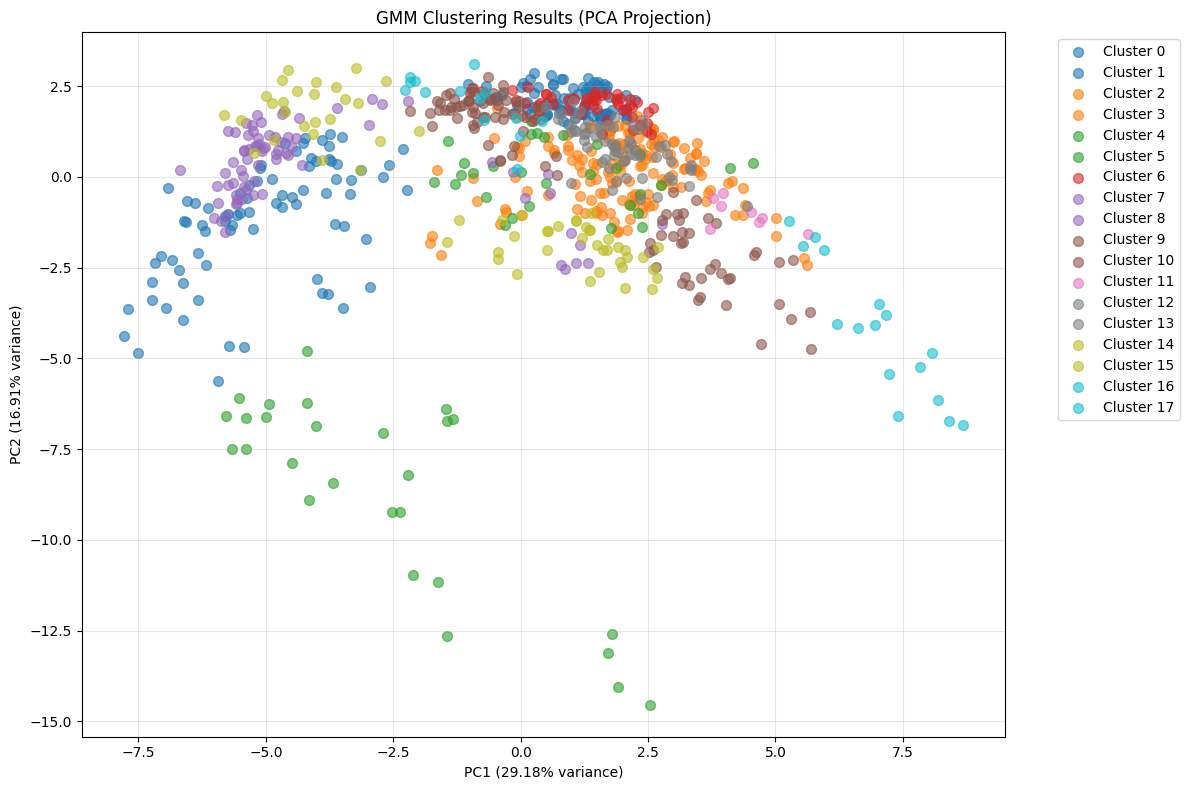


GMM Cluster Summary:

Cluster 0:
  Size: 88 locations
  Sample locations: Bihar_Aurangabad, Bihar_Gaya, Bihar_Jamui, Bihar_Kaimur (Bhabua), Bihar_Nawada
  Avg annual rainfall: 0.29
  Avg annual temp: 0.86 K

Cluster 1:
  Size: 79 locations
  Sample locations: Arunachal Pradesh_Anjaw, Arunachal Pradesh_Changlang, Arunachal Pradesh_East Kameng, Arunachal Pradesh_East Siang, Arunachal Pradesh_Itanagar Capital Complex
  Avg annual rainfall: 0.44
  Avg annual temp: 0.65 K

Cluster 2:
  Size: 80 locations
  Sample locations: Chandigarh_Chandigarh, Delhi_Central, Delhi_New Delhi, Delhi_North, Delhi_North West
  Avg annual rainfall: 0.18
  Avg annual temp: 0.76 K

Cluster 3:
  Size: 76 locations
  Sample locations: Gujarat_Arvalli, Gujarat_Mahisagar, Madhya Pradesh_Agar Malwa, Madhya Pradesh_Ashoknagar, Madhya Pradesh_Barwani
  Avg annual rainfall: 0.22
  Avg annual temp: 0.91 K

Cluster 4:
  Size: 30 locations
  Sample locations: Andhra Pradesh_Anantapur, Andhra Pradesh_Kurnool, Andhra Prade

In [12]:
gmm = GaussianMixture(n_components=n_clusters, random_state=42, 
                      covariance_type='full', n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)

# Evaluate GMM
print("\nGMM Evaluation:")
print(f"  Number of clusters: {len(np.unique(gmm_labels))}")

gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_davies_bouldin = davies_bouldin_score(X_scaled, gmm_labels)
gmm_calinski_harabasz = calinski_harabasz_score(X_scaled, gmm_labels)

print(f"  Silhouette Score: {gmm_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {gmm_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {gmm_calinski_harabasz:.2f}")

# Visualize GMM with PCA
pca_gmm = PCA(n_components=2)
X_pca_gmm = pca_gmm.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

for label in range(n_clusters):
    mask = gmm_labels == label
    plt.scatter(X_pca_gmm[mask, 0], X_pca_gmm[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_gmm.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_gmm.explained_variance_ratio_[1]:.2%} variance)')
plt.title('GMM Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GMM cluster summary
gmm_df = df.copy()
gmm_df['cluster'] = gmm_labels

print("\nGMM Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(gmm_df['cluster'].unique()):
    cluster_data = gmm_df[gmm_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_kharif_mean'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['tp_kharif_fraction'].mean():.2f} K")


In [13]:
gmm_df[['state', 'district']] = gmm_df['location'].str.split('_', expand=True)
gmm_df.to_csv('gmm_clustering_results_new.csv', index=False)

adjusted_rand_score(comparison_df['label'], gmm_df['cluster'])

0.462231991136633


Hierarchical Evaluation:
  Number of clusters: 18
  Silhouette Score: 0.2319
  Davies-Bouldin Index: 1.1369
  Calinski-Harabasz Index: 120.87


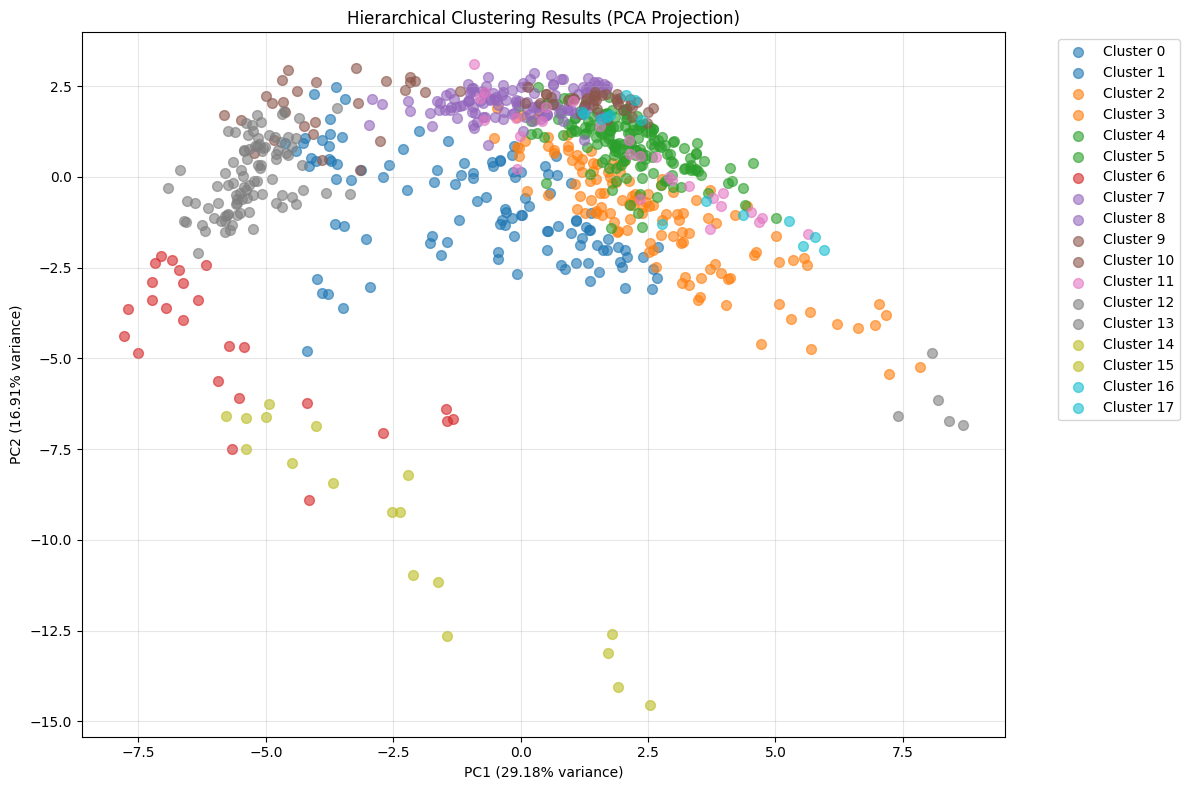


Hierarchical Cluster Summary:

Cluster 0:
  Size: 68 locations
  Sample locations: A & N Islands_North And Middle Andaman, A & N Islands_South Andamans, Andhra Pradesh_Anakapalli, Andhra Pradesh_Annamayya, Andhra Pradesh_Bapatla
  Avg annual rainfall: 0.13
  Avg annual temp: 0.45 K

Cluster 1:
  Size: 45 locations
  Sample locations: Himachal Pradesh_Bilaspur, Himachal Pradesh_Hamirpur, Himachal Pradesh_Kangra, Himachal Pradesh_Mandi, Himachal Pradesh_Shimla
  Avg annual rainfall: 0.29
  Avg annual temp: 0.67 K

Cluster 2:
  Size: 43 locations
  Sample locations: Gujarat_Banas Kantha, Gujarat_Kachchh, Haryana_Bhiwani, Haryana_Charki Dadri, Haryana_Fatehabad
  Avg annual rainfall: 0.10
  Avg annual temp: 0.80 K

Cluster 3:
  Size: 81 locations
  Sample locations: Chandigarh_Chandigarh, Delhi_Central, Delhi_New Delhi, Delhi_North, Delhi_North West
  Avg annual rainfall: 0.17
  Avg annual temp: 0.79 K

Cluster 4:
  Size: 67 locations
  Sample locations: Andhra Pradesh_Anantapur, Andhra P

In [14]:
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

# Evaluate Hierarchical
print("\nHierarchical Evaluation:")
print(f"  Number of clusters: {len(np.unique(hier_labels))}")

hier_silhouette = silhouette_score(X_scaled, hier_labels)
hier_davies_bouldin = davies_bouldin_score(X_scaled, hier_labels)
hier_calinski_harabasz = calinski_harabasz_score(X_scaled, hier_labels)

print(f"  Silhouette Score: {hier_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {hier_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {hier_calinski_harabasz:.2f}")

# Visualize Hierarchical with PCA
pca_hier = PCA(n_components=2)
X_pca_hier = pca_hier.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

for label in range(n_clusters):
    mask = hier_labels == label
    plt.scatter(X_pca_hier[mask, 0], X_pca_hier[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_hier.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_hier.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Hierarchical Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Hierarchical cluster summary
hier_df = df.copy()
hier_df['cluster'] = hier_labels

print("\nHierarchical Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(hier_df['cluster'].unique()):
    cluster_data = hier_df[hier_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_kharif_mean'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['tp_kharif_fraction'].mean():.2f} K")

In [15]:
hier_df[['state', 'district']] = hier_df['location'].str.split('_', expand=True)
hier_df.to_csv('hier_clustering_results_new.csv', index=False)

adjusted_rand_score(comparison_df['label'], hier_df['cluster'])

0.48575610606908187

In [16]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Feature names (same as your feature_cols)
feature_names = feature_cols  

# ── Helper: fit RF → compute SHAP ──────────────────────────────────────────
def get_shap_values(X, labels, feature_names, algo_name):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, labels)

    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X)  # list of arrays, one per class

    # shap_vals is a list of shape (n_classes,) each element: (n_samples, n_features)
    print(f"[{algo_name}] shap_values type: {type(shap_vals)}")
    if isinstance(shap_vals, list):
        print(f"[{algo_name}] n_classes: {len(shap_vals)}, per-class shape: {shap_vals[0].shape}")
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    else:
        # newer shap versions return a single 3D array (n_samples, n_features, n_classes)
        print(f"[{algo_name}] shap_values shape: {shap_vals.shape}")
        mean_abs_shap = np.abs(shap_vals).mean(axis=(0, 2))  # mean over samples and classes

    print(f"[{algo_name}] mean_abs_shap shape: {mean_abs_shap.shape}, feature_names: {len(feature_names)}")

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)

    print(f"\n{'='*50}")
    print(f"  SHAP Feature Importance — {algo_name}")
    print(f"{'='*50}")
    print(importance_df.to_string(index=False))

    return shap_vals, explainer, importance_df

# ── Run for each algorithm ──────────────────────────────────────────────────
shap_kmeans,  exp_kmeans,  imp_kmeans  = get_shap_values(X_scaled, kmeans_labels,  feature_names, "KMeans")
shap_gmm,     exp_gmm,     imp_gmm     = get_shap_values(X_scaled, gmm_labels,     feature_names, "GMM")
shap_hier,    exp_hier,    imp_hier    = get_shap_values(X_scaled, hier_labels,    feature_names, "Hierarchical")

[KMeans] shap_values type: <class 'numpy.ndarray'>
[KMeans] shap_values shape: (773, 35, 18)
[KMeans] mean_abs_shap shape: (35,), feature_names: 35

  SHAP Feature Importance — KMeans
                  feature  mean_abs_shap
       tp_kharif_fraction       0.010810
     humidity_variability       0.010454
             tp_zaid_mean       0.009879
            t2m_amplitude       0.009637
             t2m_peak_sin       0.007655
           swvl1_rabi_std       0.007094
              e_rabi_mean       0.006753
 soil_air_diff_kharif_std       0.006368
soil_air_diff_kharif_mean       0.005780
              e_zaid_mean       0.005748
           swvl1_zaid_std       0.005009
   runoff_ratio_rabi_mean       0.004976
           tp_kharif_mean       0.004934
                 GDD_rabi       0.004912
  soil_air_diff_rabi_mean       0.004739
soil_moisture_seasonality       0.004728
             t2m_peak_cos       0.004687
 runoff_ratio_kharif_mean       0.004477
    humidity_stress_index       0.004

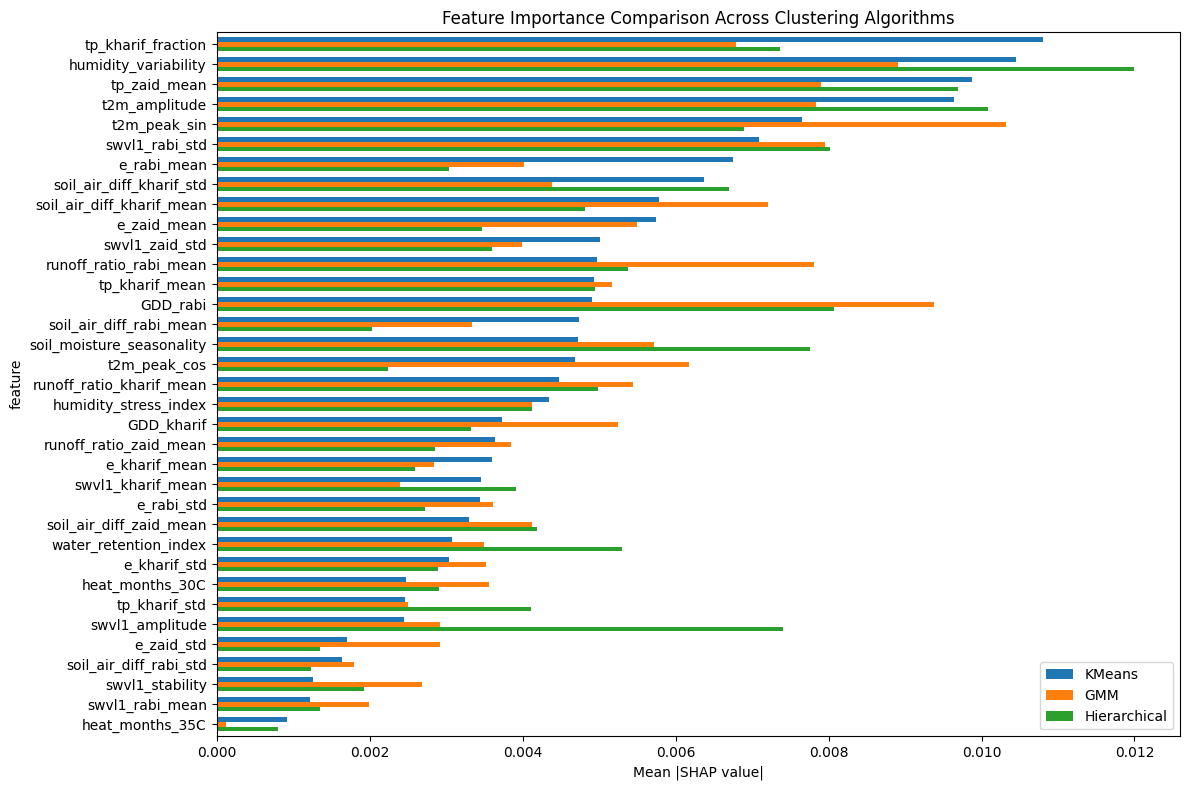

                             KMeans       GMM  Hierarchical
feature                                                    
tp_kharif_fraction         0.010810  0.006797      0.007372
humidity_variability       0.010454  0.008907      0.011995
tp_zaid_mean               0.009879  0.007902      0.009687
t2m_amplitude              0.009637  0.007833      0.010081
t2m_peak_sin               0.007655  0.010316      0.006897
swvl1_rabi_std             0.007094  0.007958      0.008020
e_rabi_mean                0.006753  0.004018      0.003042
soil_air_diff_kharif_std   0.006368  0.004380      0.006703
soil_air_diff_kharif_mean  0.005780  0.007210      0.004817
e_zaid_mean                0.005748  0.005495      0.003463
swvl1_zaid_std             0.005009  0.003995      0.003596
runoff_ratio_rabi_mean     0.004976  0.007806      0.005376
tp_kharif_mean             0.004934  0.005172      0.004952
GDD_rabi                   0.004912  0.009385      0.008075
soil_air_diff_rabi_mean    0.004739  0.0

In [17]:
import pandas as pd

comparison = (
    imp_kmeans.rename(columns={'mean_abs_shap': 'KMeans'})
    .merge(imp_gmm.rename(columns={'mean_abs_shap': 'GMM'}), on='feature')
    .merge(imp_hier.rename(columns={'mean_abs_shap': 'Hierarchical'}), on='feature')
    .set_index('feature')
    .sort_values('KMeans', ascending=False)
)

comparison.plot(kind='barh', figsize=(12, 8), width=0.7)
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance Comparison Across Clustering Algorithms")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("shap_comparison_bar.png", dpi=150, bbox_inches='tight')
plt.show()

print(comparison.to_string())

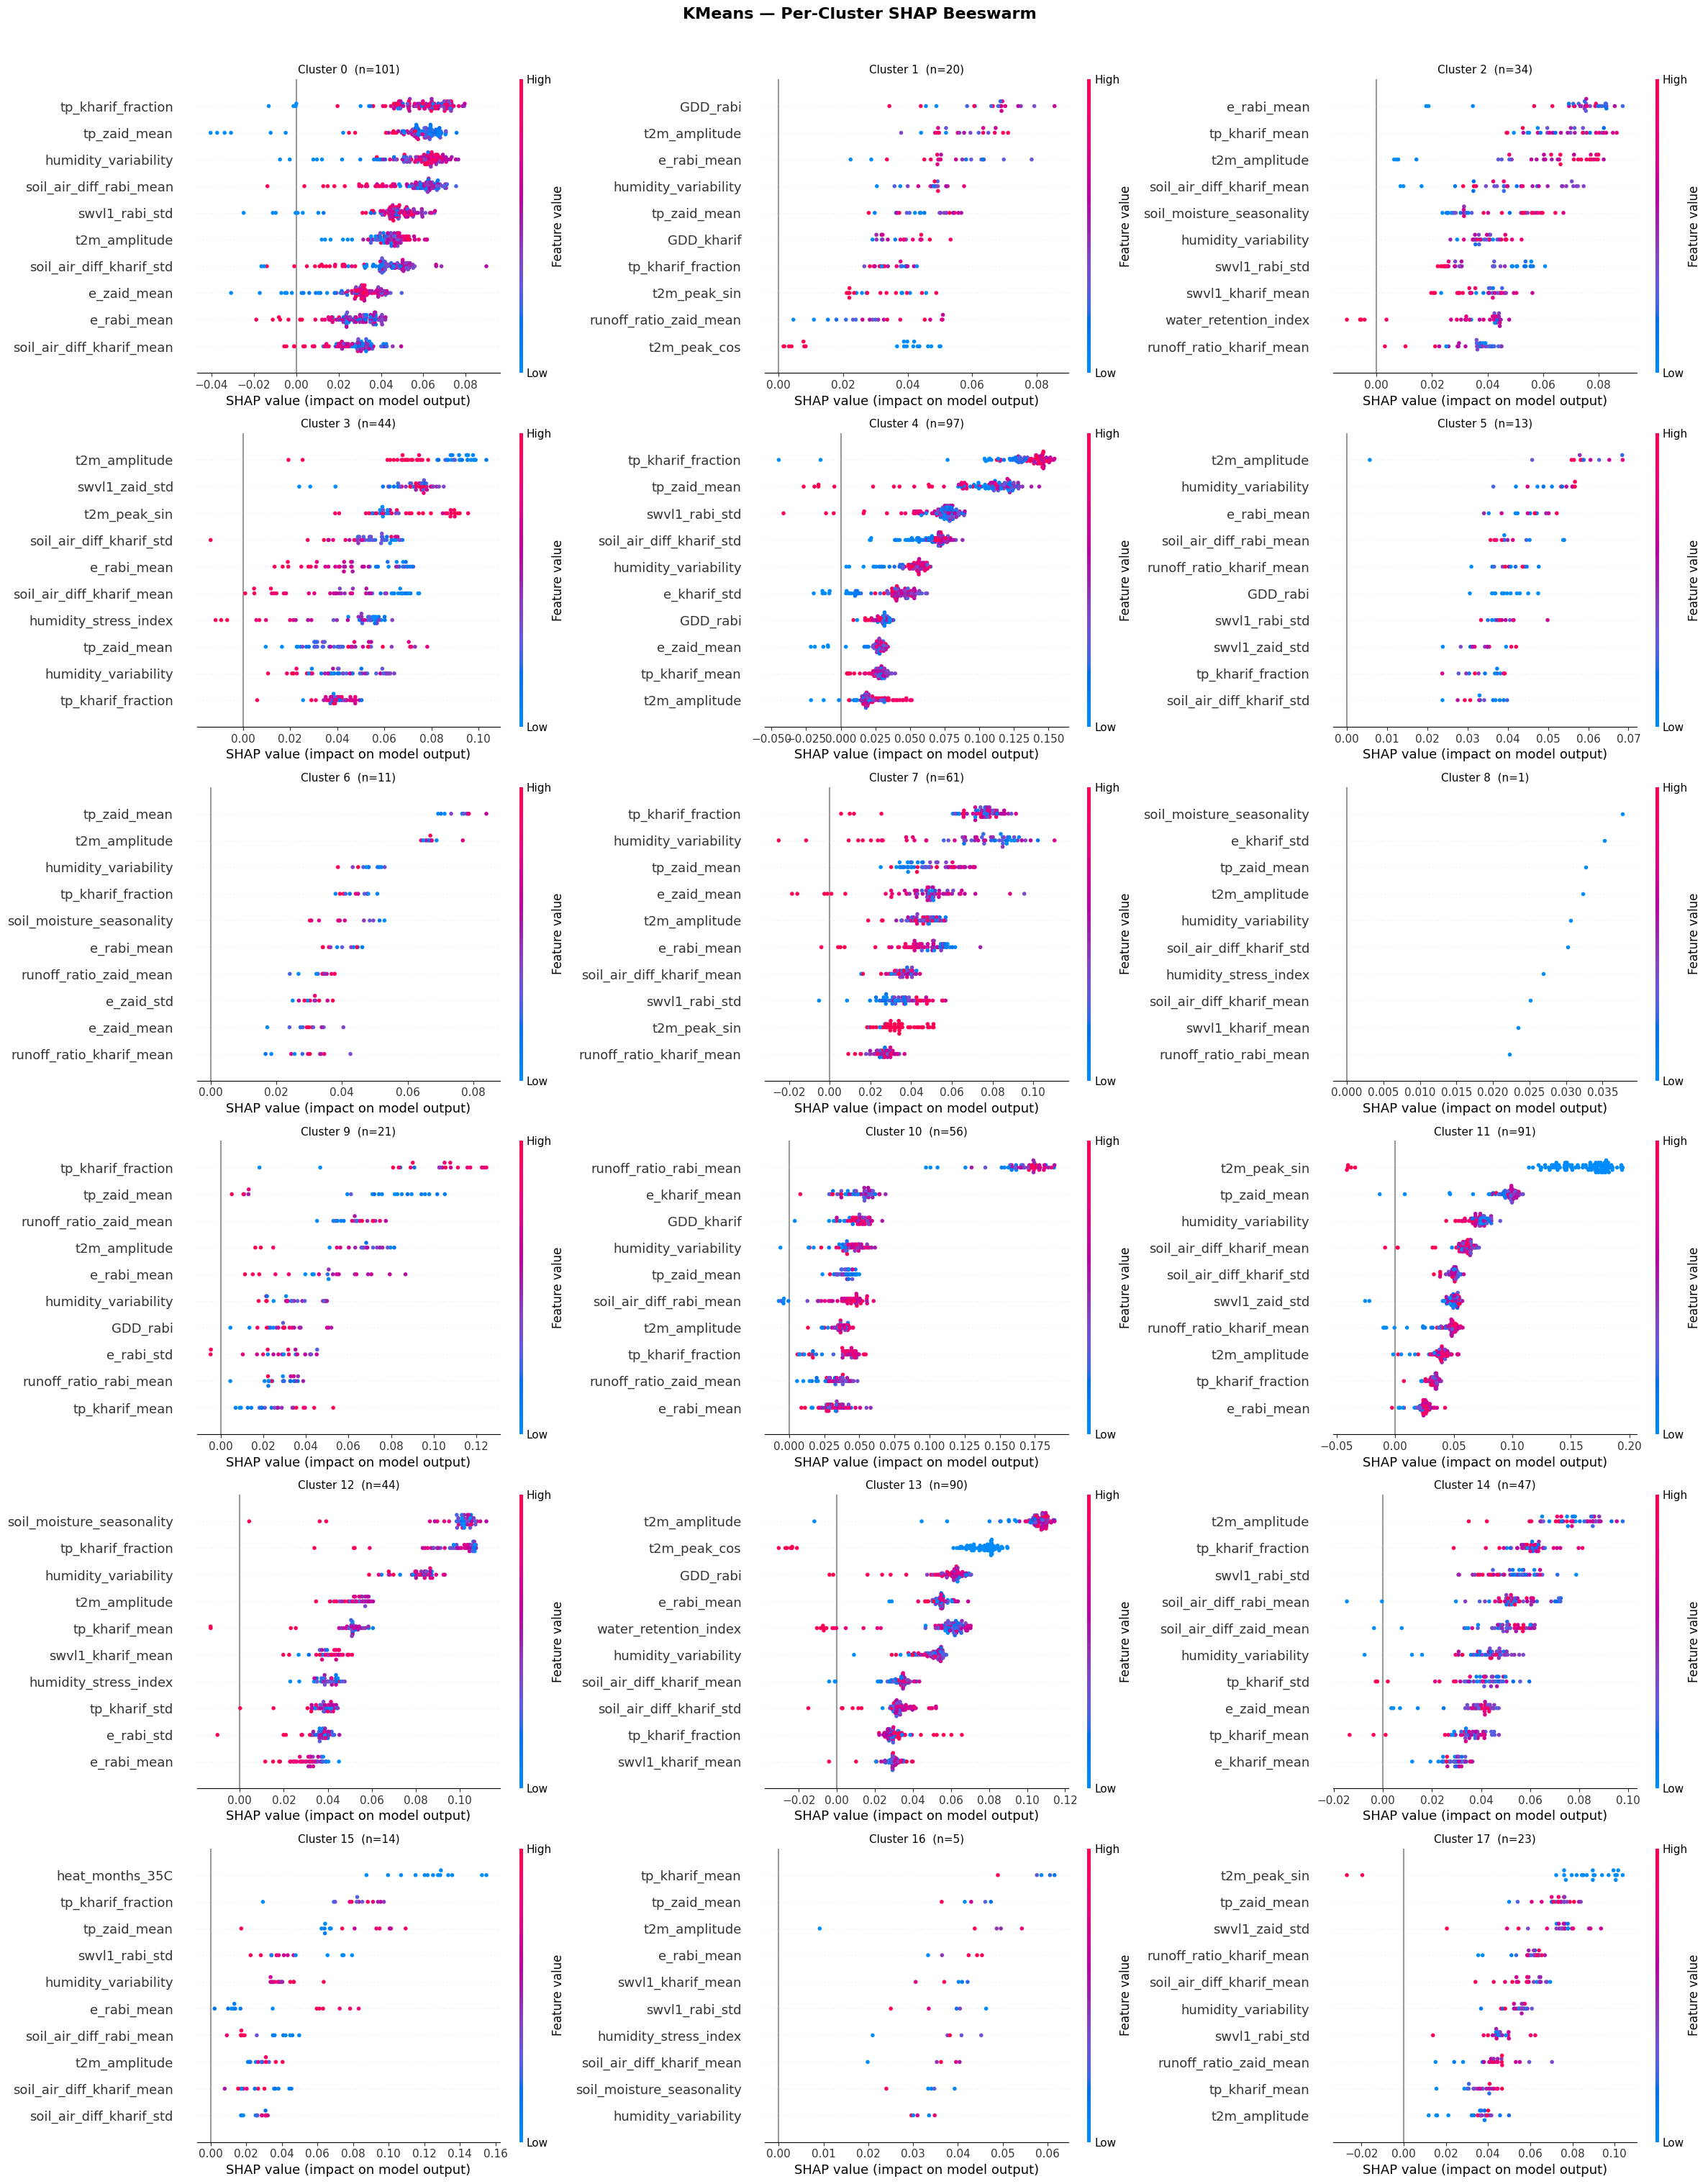

Saved: shap_beeswarm_kmeans.png


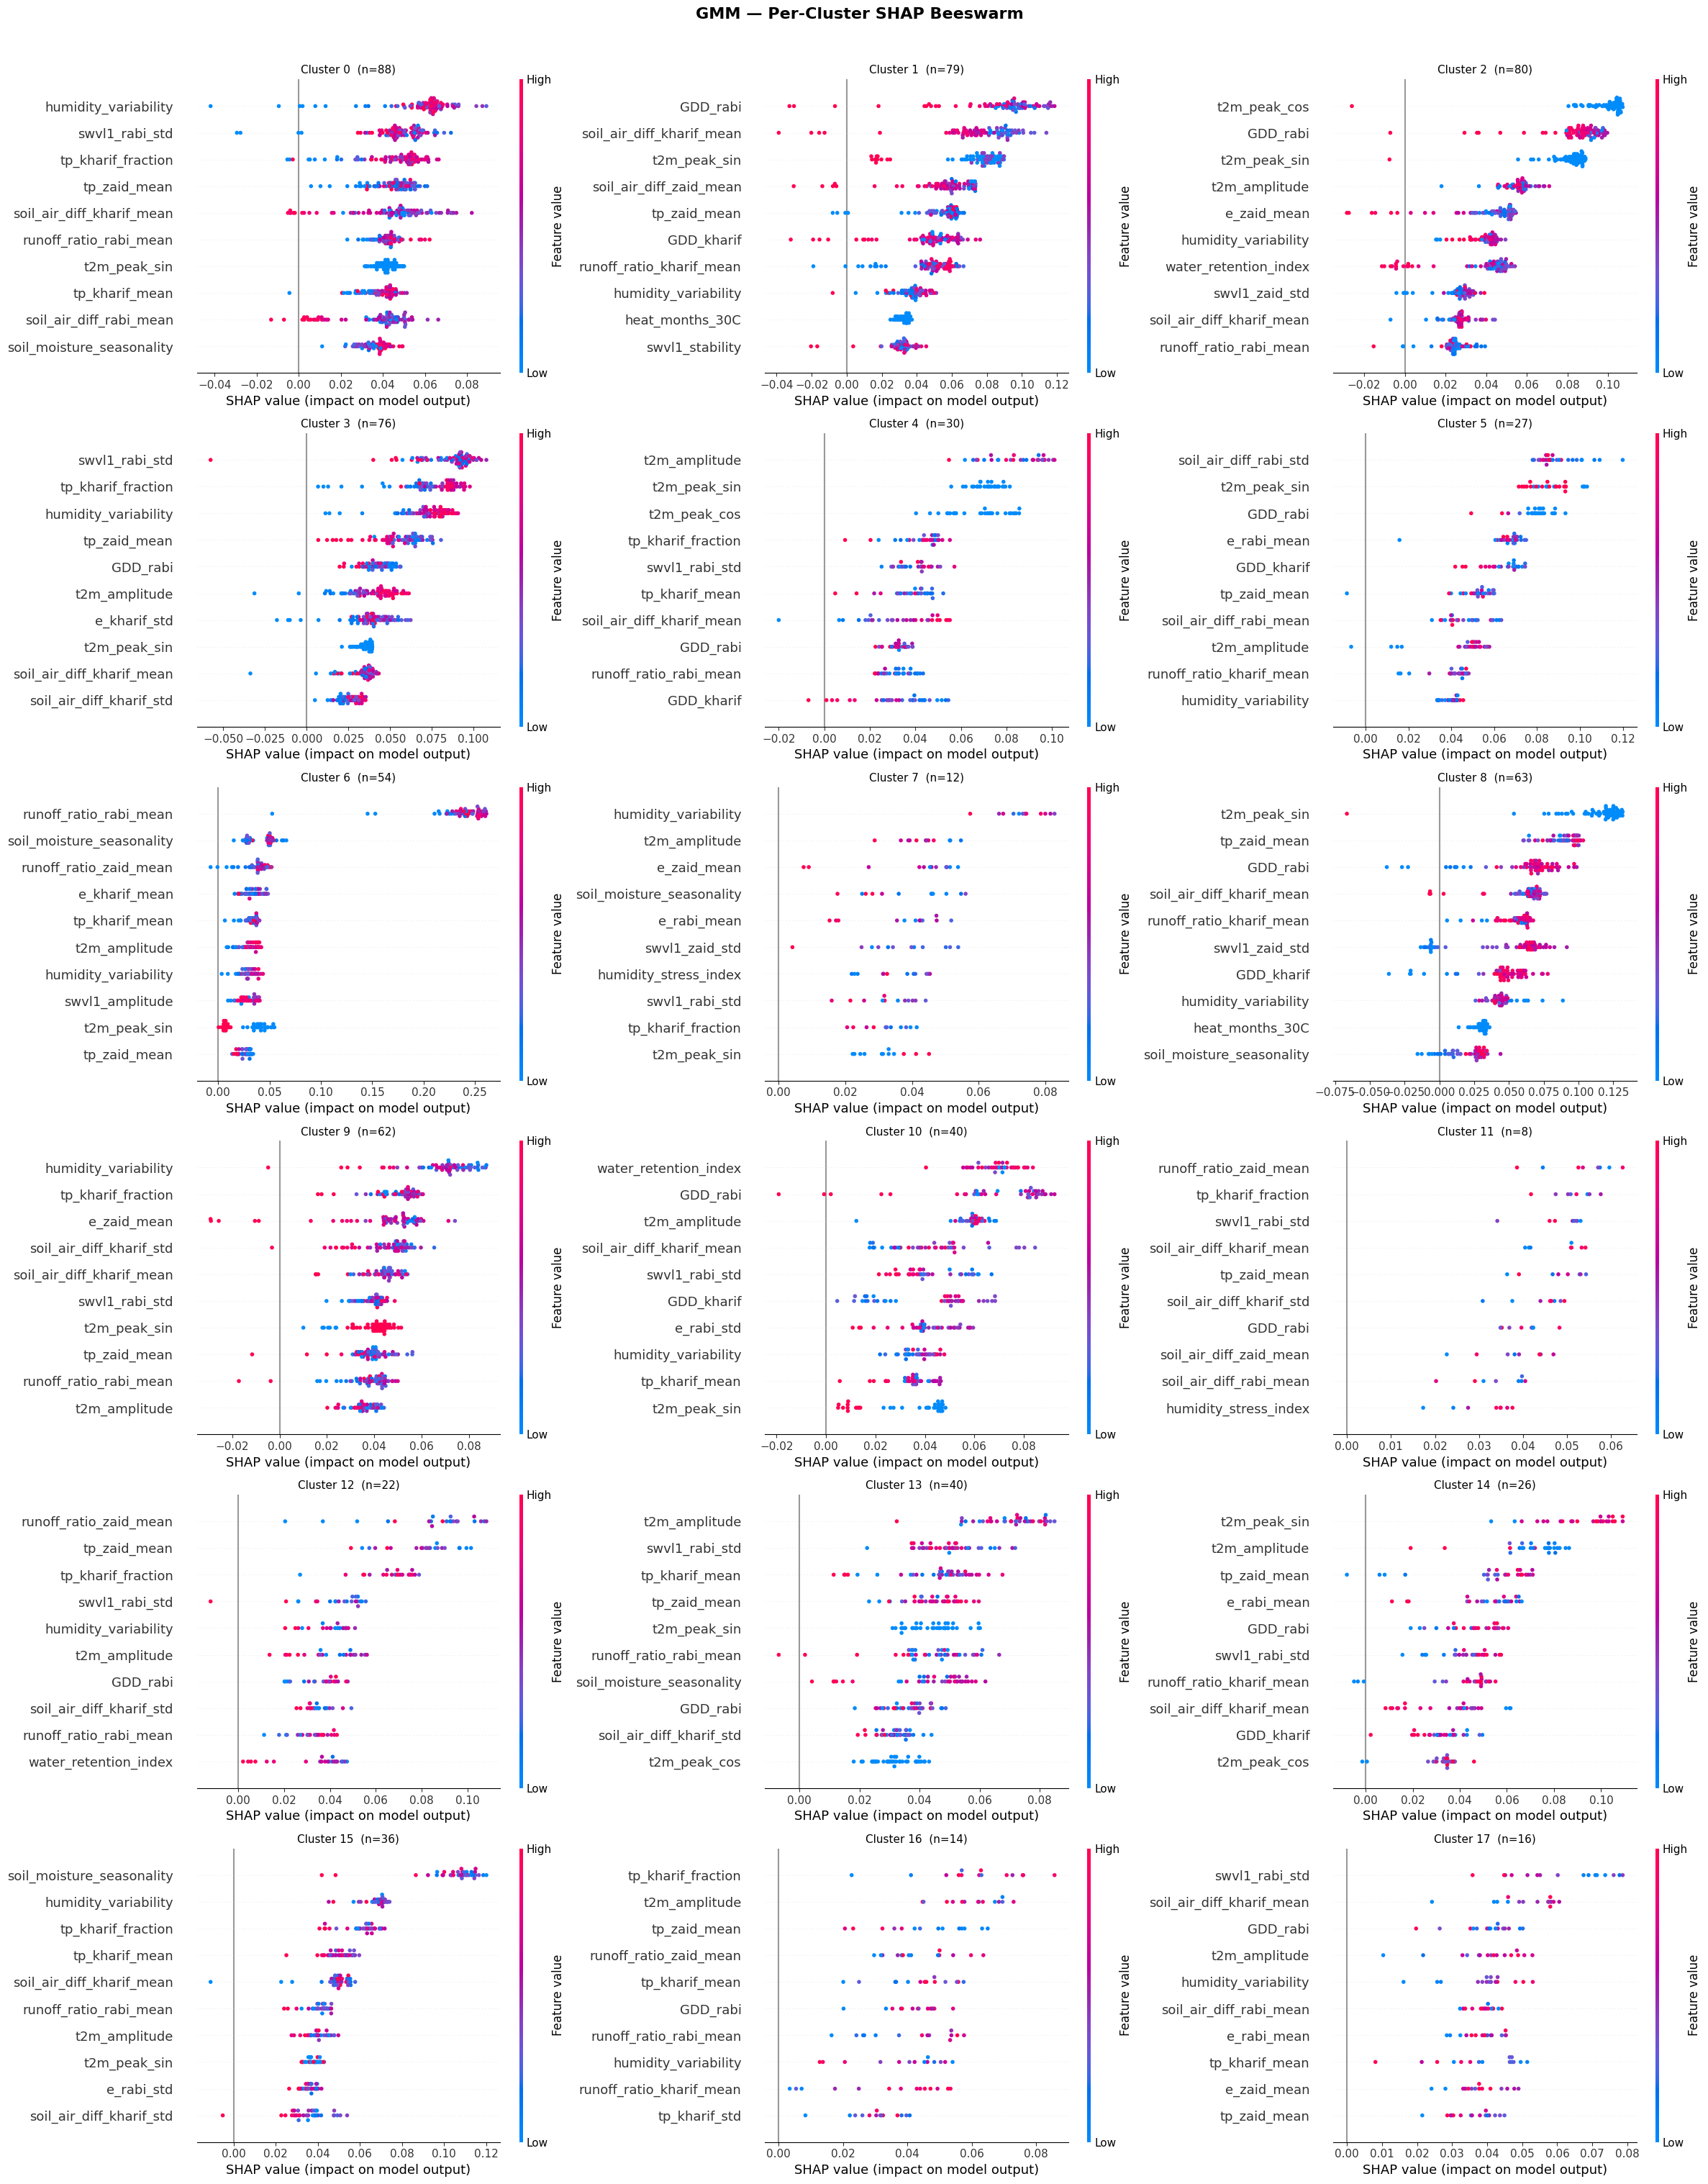

Saved: shap_beeswarm_gmm.png


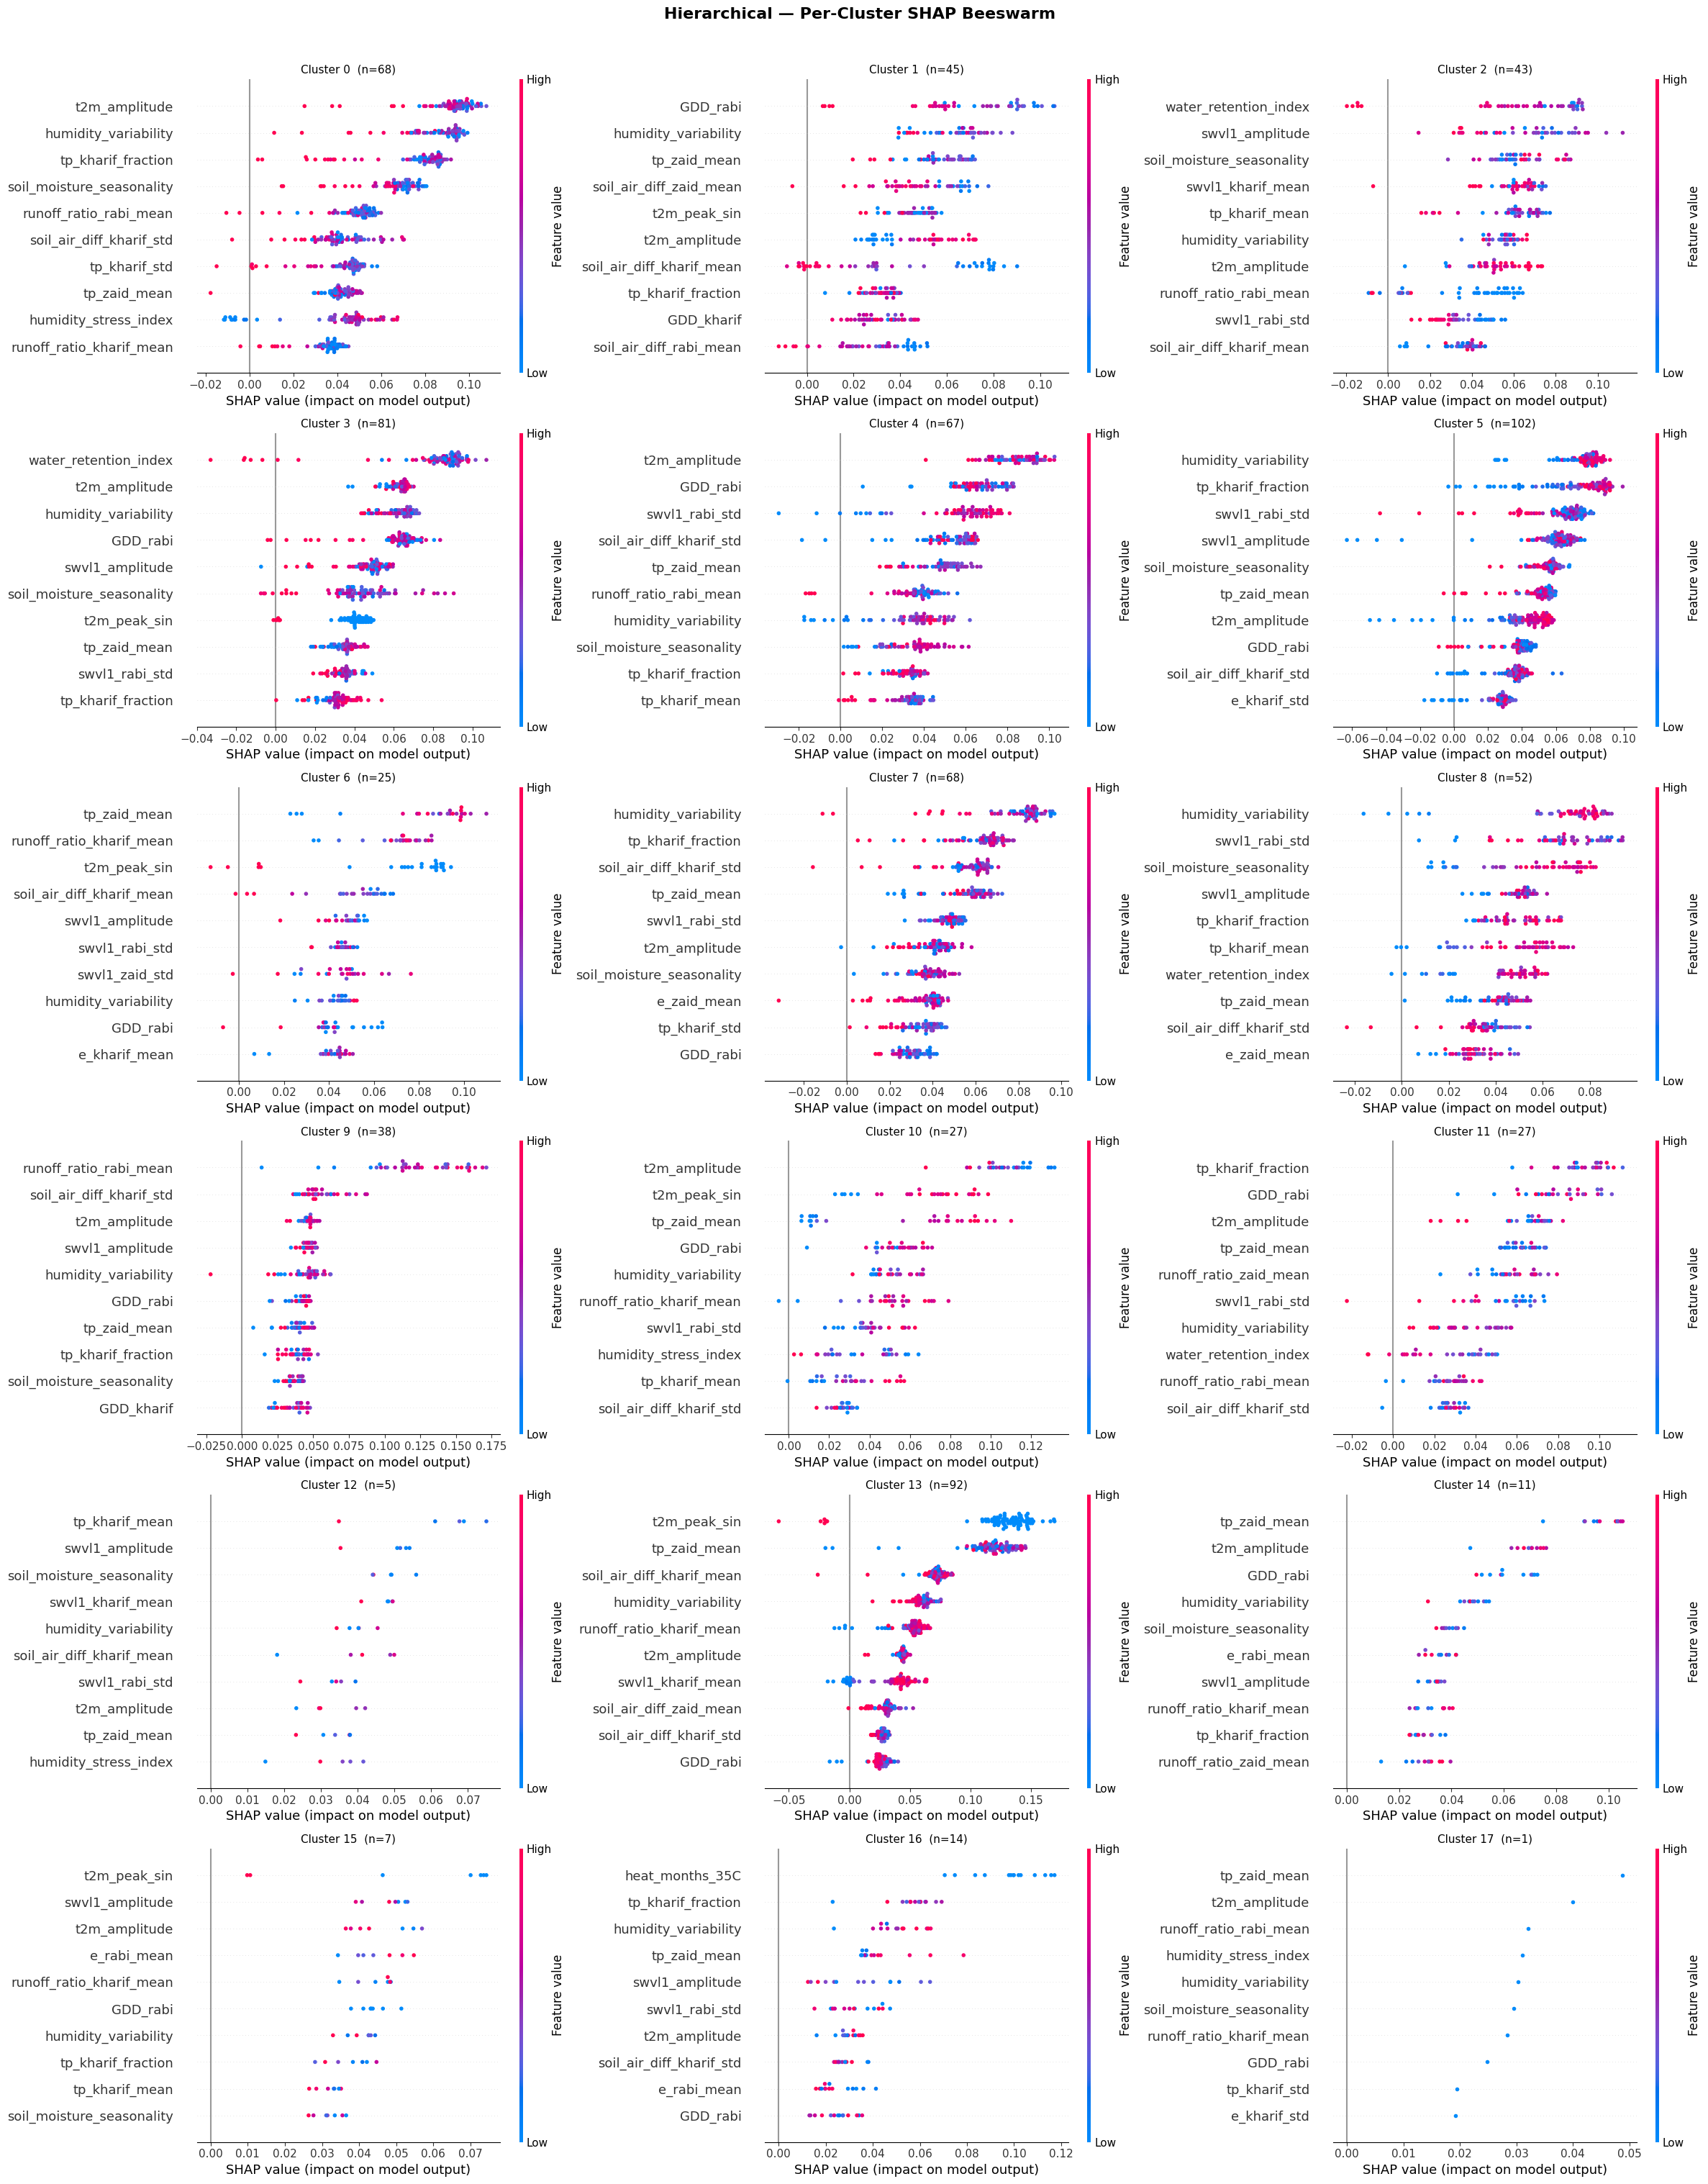

Saved: shap_beeswarm_hierarchical.png


In [18]:
import math

for algo_name, shap_vals, labels in [
    ("KMeans",       shap_kmeans, kmeans_labels),
    ("GMM",          shap_gmm,    gmm_labels),
    ("Hierarchical", shap_hier,   hier_labels),
]:
    unique_clusters = sorted(np.unique(labels))
    n_cols = 3
    n_rows = math.ceil(len(unique_clusters) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 5))
    axes = axes.flatten()
    fig.suptitle(f"{algo_name} — Per-Cluster SHAP Beeswarm", fontsize=16, fontweight='bold', y=1.01)

    for i, cluster_id in enumerate(unique_clusters):
        mask         = labels == cluster_id
        class_shap   = shap_vals[:, :, cluster_id]   # (n_samples, n_features)
        cluster_shap = class_shap[mask, :]
        cluster_X    = X_scaled[mask, :]

        plt.sca(axes[i])
        shap.summary_plot(
            cluster_shap,
            cluster_X,
            feature_names=feature_names,
            show=False,
            plot_size=None,
            max_display=10         # top 10 features per cluster to keep it readable
        )
        axes[i].set_title(f"Cluster {cluster_id}  (n={mask.sum()})", fontsize=11)

    # hide unused subplots
    for j in range(len(unique_clusters), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"shap_beeswarm_{algo_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_beeswarm_{algo_name.lower()}.png")

C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_4828\1692706992.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap    = cm.get_cmap('tab20', n_clusters)


[KMeans] Matched: 773 / 785


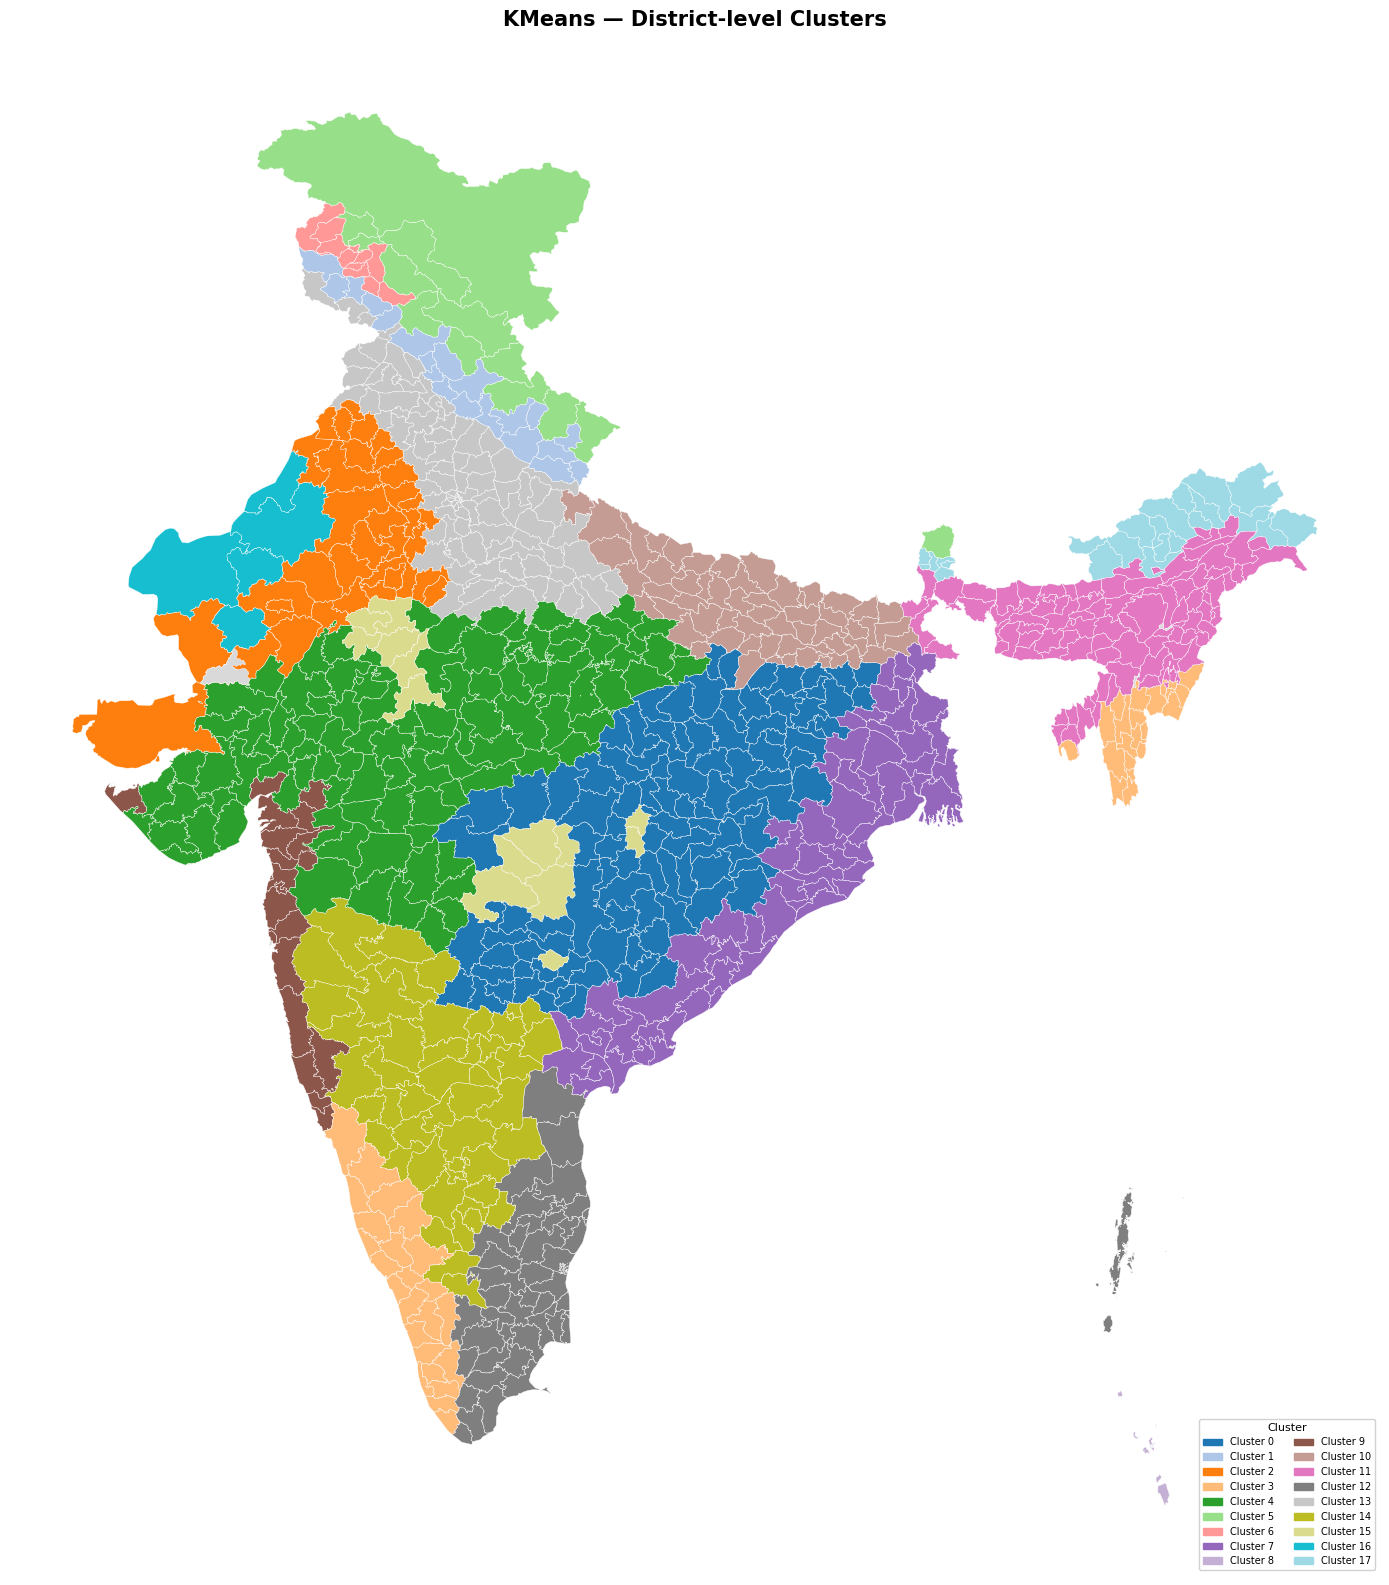

Saved: choropleth_kmeans.png
[GMM] Matched: 773 / 785


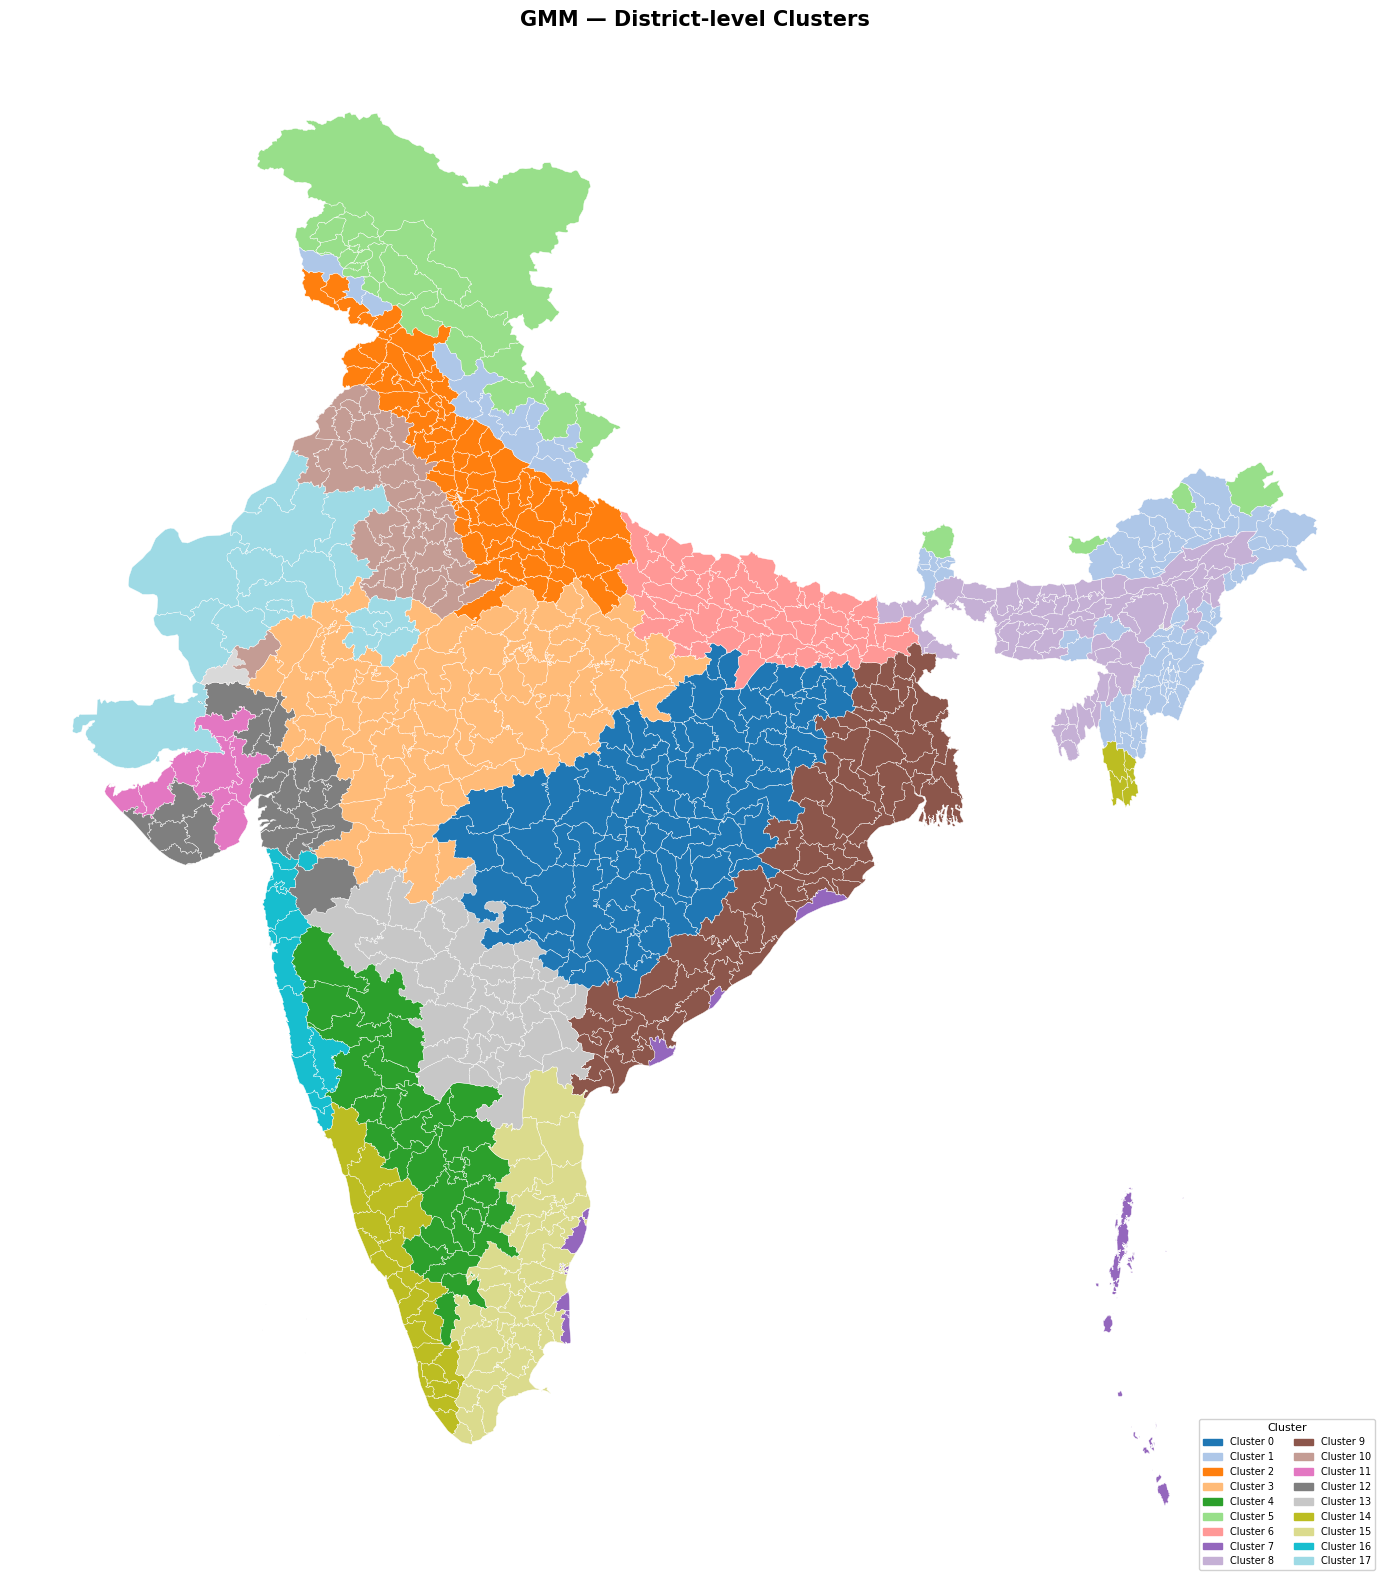

Saved: choropleth_gmm.png
[Hierarchical] Matched: 773 / 785


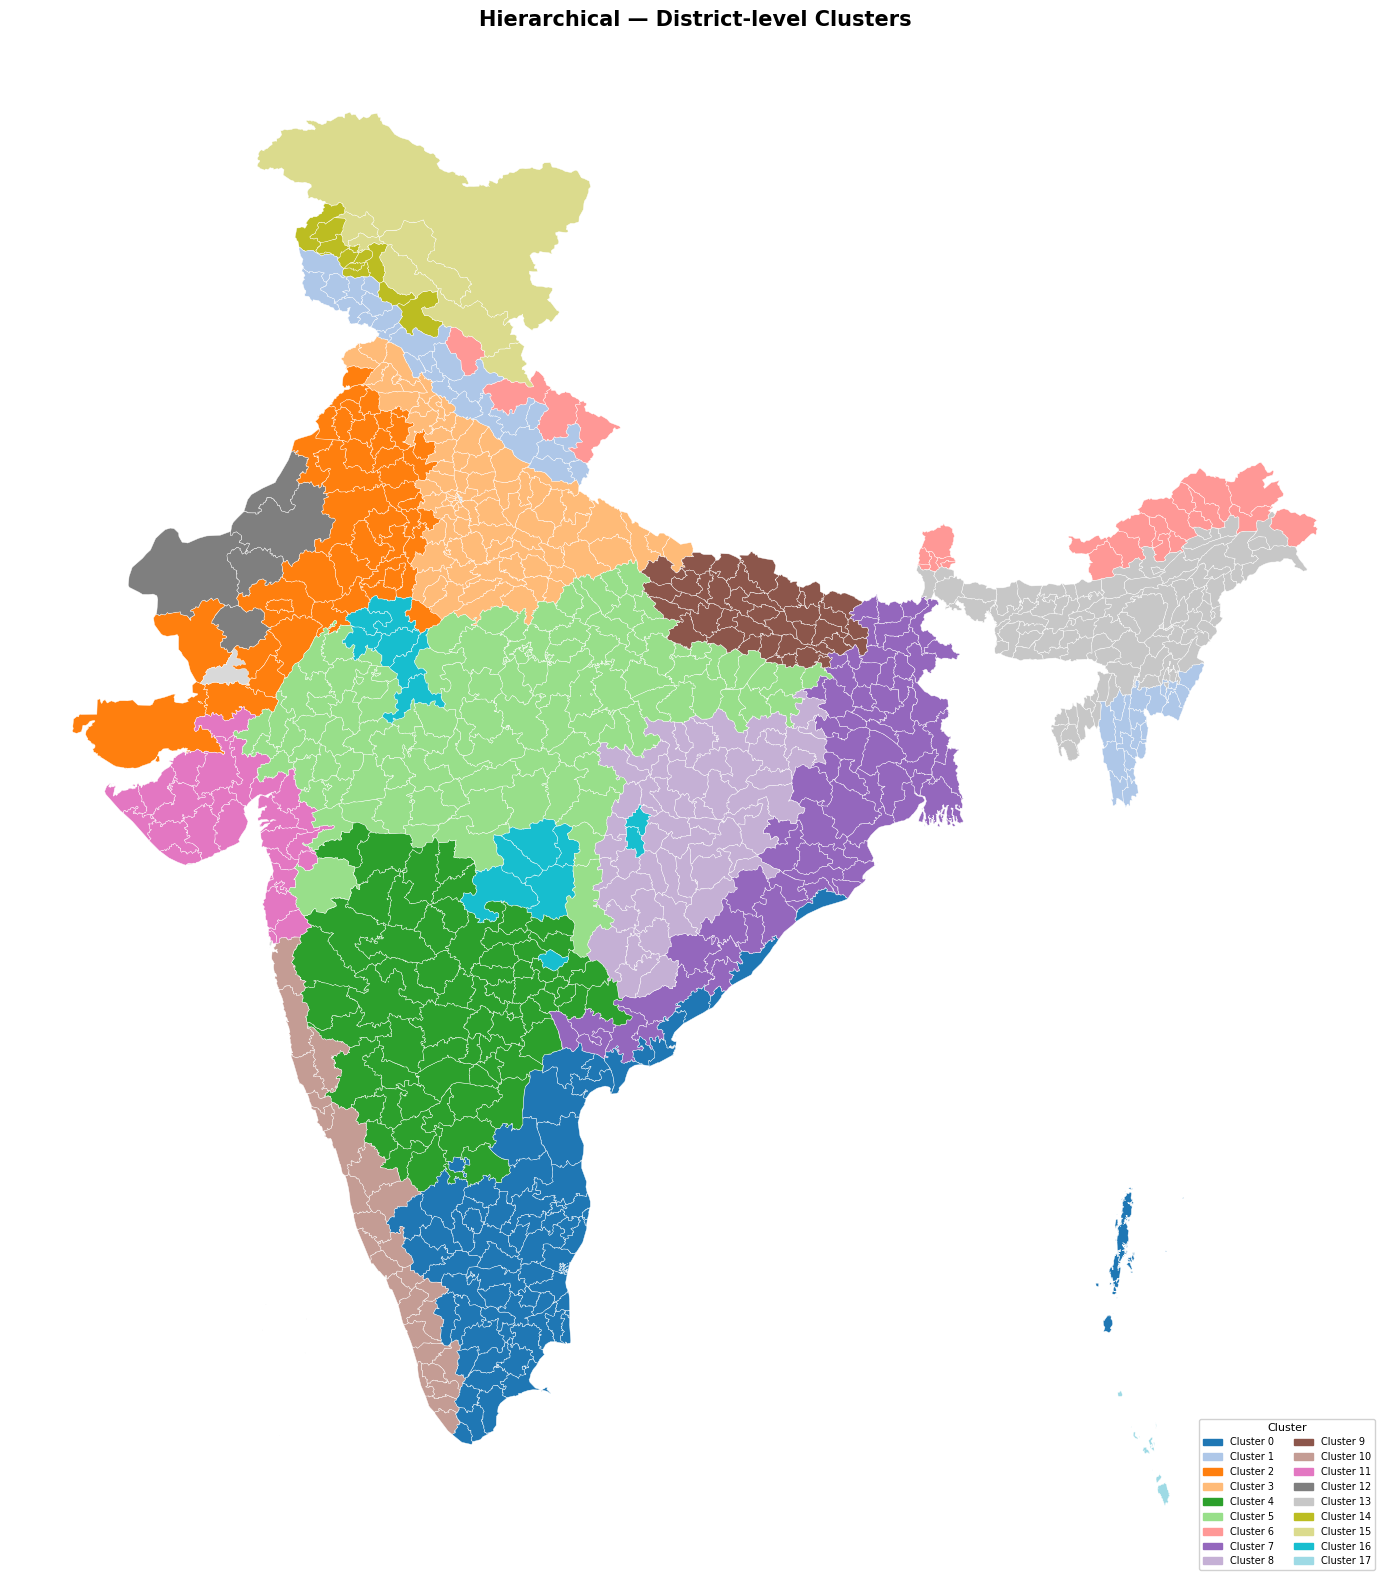

Saved: choropleth_hierarchical.png


In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np
import requests, io

geojson_url = "https://raw.githubusercontent.com/saketlab/bharatviz/refs/heads/main/public/India_LGD_districts.geojson"
gdf = gpd.read_file(io.BytesIO(requests.get(geojson_url).content))

# Normalize join keys
gdf['district_norm'] = gdf['district_name'].str.strip().str.title()
gdf['state_norm']    = gdf['state_name'].str.strip().str.title()

# Color palette — one color per cluster
cmap    = cm.get_cmap('tab20', n_clusters)
colors  = {i: cmap(i) for i in range(n_clusters)}

for algo_name, df in [
    ("KMeans",       kmeans_df),
    ("GMM",          gmm_df),
    ("Hierarchical", hier_df),
]:
    plot_df = df[['state', 'district', 'cluster']].copy()
    plot_df['district_norm'] = plot_df['district'].str.strip().str.title()
    plot_df['state_norm']    = plot_df['state'].str.strip().str.title()

    # Merge cluster info into geodataframe
    merged = gdf.merge(
        plot_df[['state_norm', 'district_norm', 'cluster']],
        on=['state_norm', 'district_norm'],
        how='left'
    )

    matched = merged['cluster'].notna().sum()
    print(f"[{algo_name}] Matched: {matched} / {len(gdf)}")

    merged['color'] = merged['cluster'].apply(
        lambda c: colors[int(c)] if pd.notna(c) else (0.85, 0.85, 0.85, 1)  # grey for unmatched
    )

    fig, ax = plt.subplots(1, 1, figsize=(14, 16))

    merged.plot(
        ax=ax,
        color=merged['color'].tolist(),
        edgecolor='white',
        linewidth=0.3
    )

    # Legend
    patches = [
        mpatches.Patch(color=colors[i], label=f'Cluster {i}')
        for i in range(n_clusters)
    ]
    ax.legend(
        handles=patches,
        loc='lower right',
        ncol=2,
        fontsize=7,
        title='Cluster',
        title_fontsize=8,
        framealpha=0.9
    )

    ax.set_title(f"{algo_name} — District-level Clusters", fontsize=15, fontweight='bold', pad=12)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(f"choropleth_{algo_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: choropleth_{algo_name.lower()}.png")

In [20]:
comparison_df['kmeans_cluster']  = kmeans_df['cluster'].values
comparison_df['gmm_cluster']     = gmm_df['cluster'].values
comparison_df['hier_cluster']    = hier_df['cluster'].values

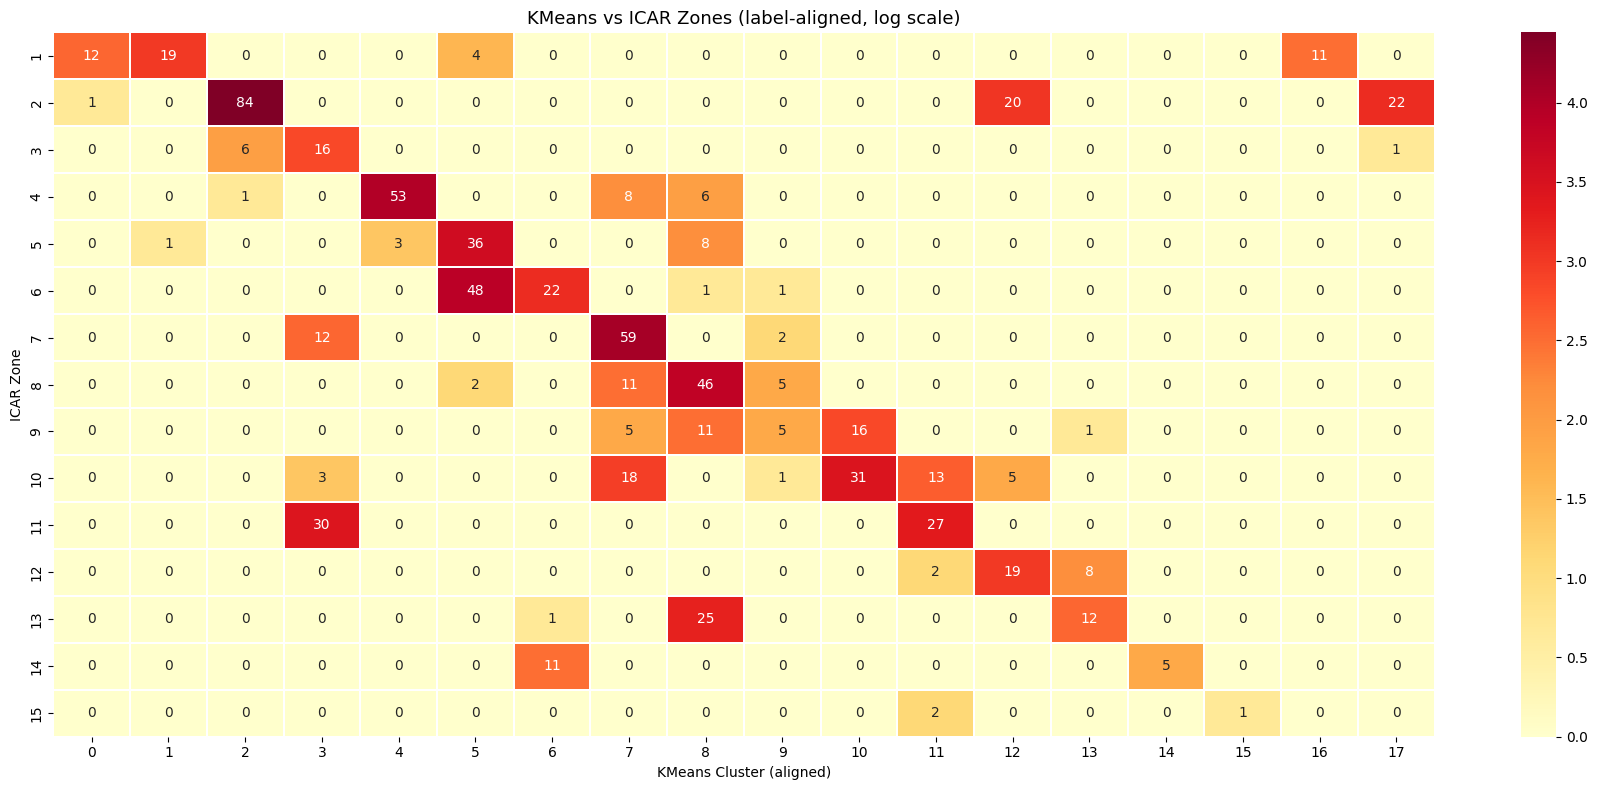

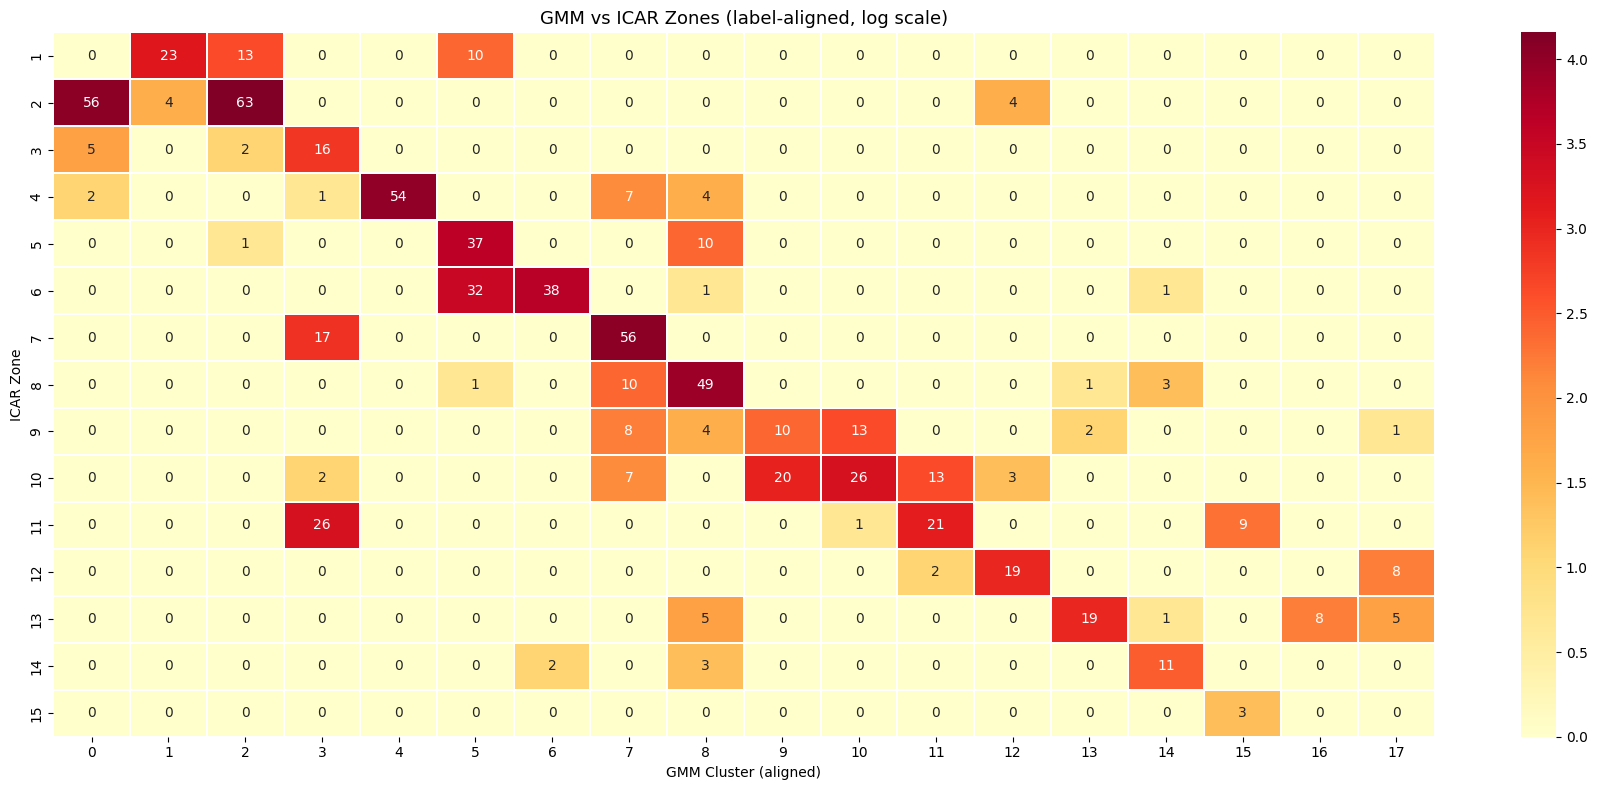

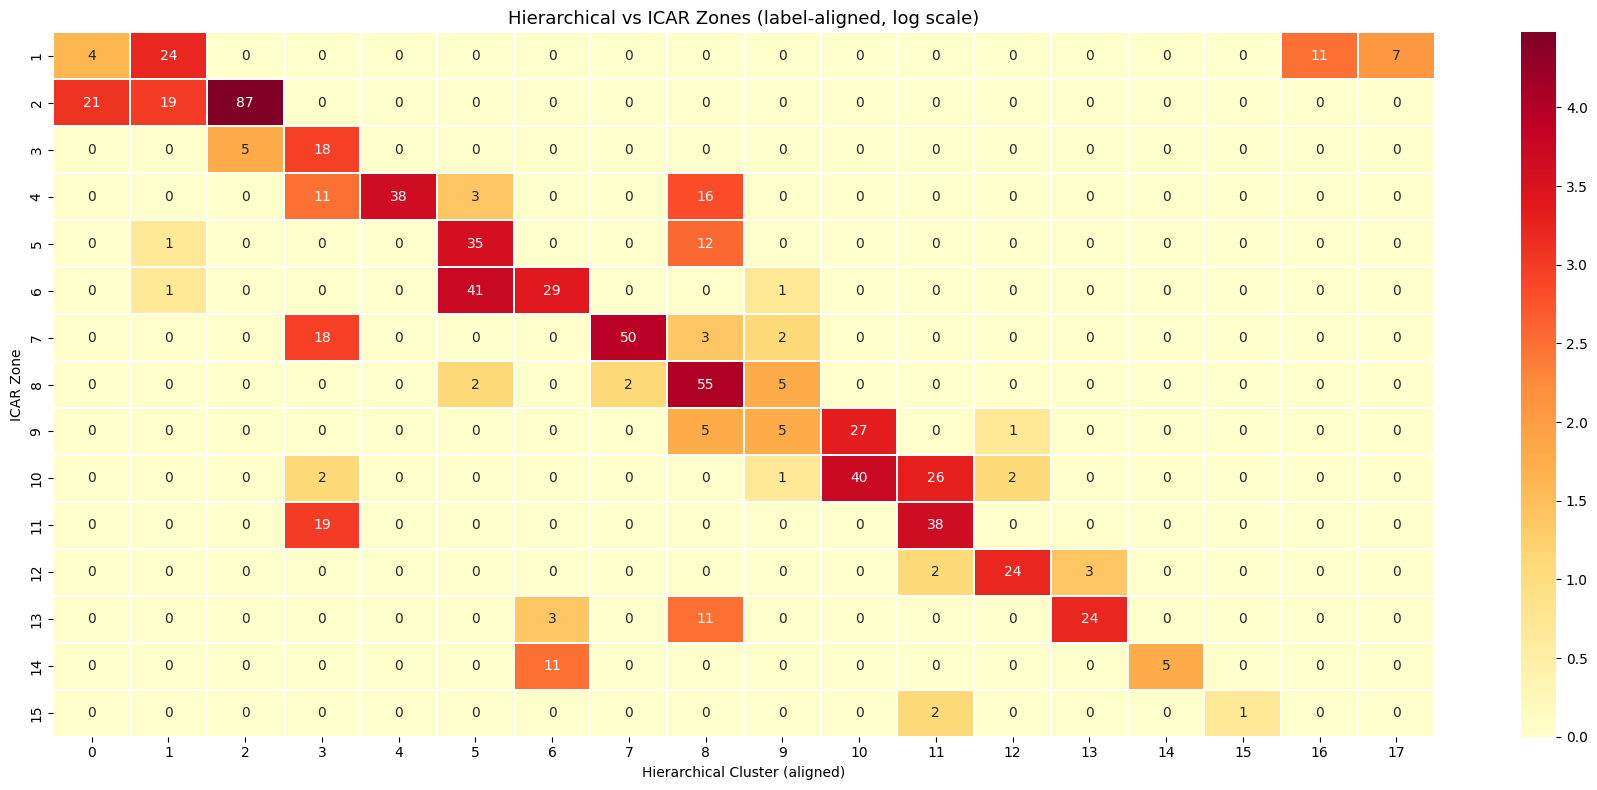

In [21]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import seaborn as sns

def align_labels(true_labels, pred_labels):
    """Remap cluster IDs to best match reference labels via Hungarian algorithm"""
    # true may have 15 classes, pred has 18 — pad to square
    n = max(true_labels.max() + 1, pred_labels.max() + 1)
    cm = confusion_matrix(true_labels, pred_labels, labels=list(range(n)))
    # maximize overlap = minimize negative
    row_ind, col_ind = linear_sum_assignment(-cm)
    # col_ind[i] = which cluster maps to ICAR zone i
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    remapped = np.array([mapping.get(l, -1) for l in pred_labels])
    return remapped

# Align all three
kmeans_aligned = align_labels(comparison_df['label'].values, kmeans_df['cluster'].values)
gmm_aligned    = align_labels(comparison_df['label'].values, gmm_df['cluster'].values)
hier_aligned   = align_labels(comparison_df['label'].values, hier_df['cluster'].values)

for algo_name, aligned in [('KMeans', kmeans_aligned), ('GMM', gmm_aligned), ('Hierarchical', hier_aligned)]:
    ct = pd.crosstab(
        comparison_df['label'],
        aligned,
        rownames=['ICAR Zone'],
        colnames=[f'{algo_name} Cluster (aligned)']
    )

    plt.figure(figsize=(18, 8))
    sns.heatmap(
        np.log1p(ct),          # log scale — log1p avoids log(0)
        annot=ct.values,       # show raw counts, not log values
        fmt='d',
        cmap='YlOrRd',
        linewidths=0.3
    )
    plt.title(f"{algo_name} vs ICAR Zones (label-aligned, log scale)", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"icar_vs_{algo_name.lower()}_aligned.png", dpi=150, bbox_inches='tight')
    plt.show()